#  Toyota Stock Price Prediction — Linear Regression (Lag Features)

**Dataset:** `Toyota_Stock_Prices_1980_2026.csv`  
**Task:** Regression dengan Lag Features  
**Model:** Ridge Regression (regularized Linear Regression)

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries loaded ')

Libraries loaded 


---
## 1.  Cara Melihat Tipe Data

In [2]:
df = pd.read_csv('../Toyota_Stock_Prices_1980_2026.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(df.shape); df.info()
df.head()

(11508, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11508 entries, 0 to 11507
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    11508 non-null  datetime64[ns]
 1   Close   11508 non-null  float64       
 2   High    11508 non-null  float64       
 3   Low     11508 non-null  float64       
 4   Open    11508 non-null  float64       
 5   Volume  11508 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 539.6 KB


,Date,Close,High,Low,Open,Volume
0,1980-03-18,1.8207,1.8501,1.8207,1.8207,9343
1,1980-03-19,1.8207,1.8207,1.8207,1.8207,0
2,1980-03-20,1.8207,1.8501,1.8207,1.8207,10277
3,1980-03-21,1.8649,1.8944,1.8649,1.8649,8409
4,1980-03-24,1.8723,1.9017,1.8723,1.8723,2803


---
## 2.  Dataset Bisa Digunakan Untuk Apa

**Mengapa Linear Regression berguna untuk stock meski sederhana?**

- **Interpretable** — koefisien langsung menunjukkan pengaruh tiap fitur
- **Baseline yang kuat** — jika Ridge tidak kalah jauh dari XGBoost, data mungkin linear
- **Cepat** — training dalam millisecond
- **Tidak overfit** berkat regularisasi (Ridge/Lasso)

**Random Walk Hypothesis:** Secara teori, harga saham mengikuti random walk dan tidak bisa diprediksi. Namun dalam praktik, ada pola jangka pendek yang bisa dieksploitasi.

In [3]:
def create_features(df_in, lags=[1,2,3,5,10,20]):
    d = df_in.copy()
    for lag in lags:
        d[f'close_lag_{lag}'] = d['Close'].shift(lag)
    for w in [5, 10, 20, 50]:
        d[f'ma_{w}'] = d['Close'].rolling(w).mean()
    for n in [1, 5, 20]:
        d[f'roc_{n}'] = d['Close'].pct_change(n)
    d['vol_10']   = d['Close'].rolling(10).std()
    d['daily_range'] = d['High'] - d['Low']
    d['day_of_week'] = d['Date'].dt.dayofweek
    d['month']     = d['Date'].dt.month
    d['target']    = d['Close'].shift(-1)
    return d.dropna()

df_feat = create_features(df[df['Date'] >= '2010-01-01'].copy())
print(f'Dataset: {df_feat.shape}')

exclude = ['Date', 'target', 'Close', 'Open', 'High', 'Low', 'Volume']
feature_cols = [c for c in df_feat.columns if c not in exclude]
X = df_feat[feature_cols].values
y = df_feat['target'].values

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Dataset: (3994, 24)
Train: (3195, 17), Test: (799, 17)


---
## 3.  Model Linear dan Variannya

| Model | Regularisasi | Persamaan |
|-------|-------------|----------|
| **Linear Regression** | Tidak ada | Minimize $\|y - Xw\|^2$ |
| **Ridge** | L2 | Minimize $\|y - Xw\|^2 + \alpha\|w\|^2$ |
| **Lasso** | L1 | Minimize $\|y - Xw\|^2 + \alpha\|w\|_1$ |
| **ElasticNet** | L1 + L2 | Kombinasi Ridge dan Lasso |

**Untuk stock prediction:** Ridge biasanya lebih baik dari Linear (mengurangi multikolinearitas antar lag features)

In [4]:
# Pipeline: scaling + Ridge
model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])
model.fit(X_train, y_train)
print('Ridge training selesai ')

Ridge training selesai 


---
## 4.  Parameter Yang Bisa Diubah / Disetel

| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `alpha` (Ridge/Lasso) | 1.0 | Kekuatan regularisasi |
| `fit_intercept` | True | Apakah menghitung intercept |
| `normalize` | False | (deprecated, gunakan Scaler) |
| `max_iter` (Lasso) | 1000 | Iterasi solver |
| `l1_ratio` (ElasticNet) | 0.5 | Proporsi L1 vs L2 |

### Memilih alpha:
Gunakan `RidgeCV` untuk otomatis mencari alpha terbaik menggunakan cross-validation.

In [5]:
# Bandingkan beberapa model linear
from sklearn.linear_model import ElasticNet, Lasso

models = {
    'LinearRegression': Pipeline([('s', StandardScaler()), ('m', LinearRegression())]),
    'Ridge(α=0.1)':     Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=0.1))]),
    'Ridge(α=1.0)':     Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'Ridge(α=10)':      Pipeline([('s', StandardScaler()), ('m', Ridge(alpha=10.0))]),
    'Lasso(α=0.01)':    Pipeline([('s', StandardScaler()), ('m', Lasso(alpha=0.01))]),
    'ElasticNet':       Pipeline([('s', StandardScaler()), ('m', ElasticNet(alpha=0.1, l1_ratio=0.5))])
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    yp = mdl.predict(X_test)
    results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, yp)),
        'R²': r2_score(y_test, yp),
        'MAPE': np.mean(np.abs((y_test - yp) / (y_test + 1e-8))) * 100
    }

res_df = pd.DataFrame(results).T.sort_values('RMSE')
print('Perbandingan model:')
print(res_df.to_string())

Perbandingan model:
                      RMSE        R²      MAPE
LinearRegression  3.382063  0.985976  1.343050
Ridge(α=0.1)      3.403769  0.985796  1.349926
Lasso(α=0.01)     3.474829  0.985197  1.376503
Ridge(α=1.0)      3.487074  0.985092  1.383792
Ridge(α=10)       3.829548  0.982020  1.529528
ElasticNet        4.381498  0.976463  1.742337


---
## 5.  Evaluasi Yang Dipakai

In [6]:
best_name = res_df.index[0]
best_mdl  = models[best_name]
y_pred = best_mdl.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-8))) * 100
dir_acc = np.mean(np.sign(np.diff(y_test)) == np.sign(np.diff(y_pred))) * 100

print(f'Best Model: {best_name}')
print('='*50)
print(f'MAE            : {mae:.4f}')
print(f'RMSE           : {rmse:.4f}')
print(f'R²             : {r2:.4f}')
print(f'MAPE           : {mape:.2f}%')
print(f'Directional Acc: {dir_acc:.2f}%')

Best Model: LinearRegression
MAE            : 2.4274
RMSE           : 3.3821
R²             : 0.9860
MAPE           : 1.34%
Directional Acc: 50.13%


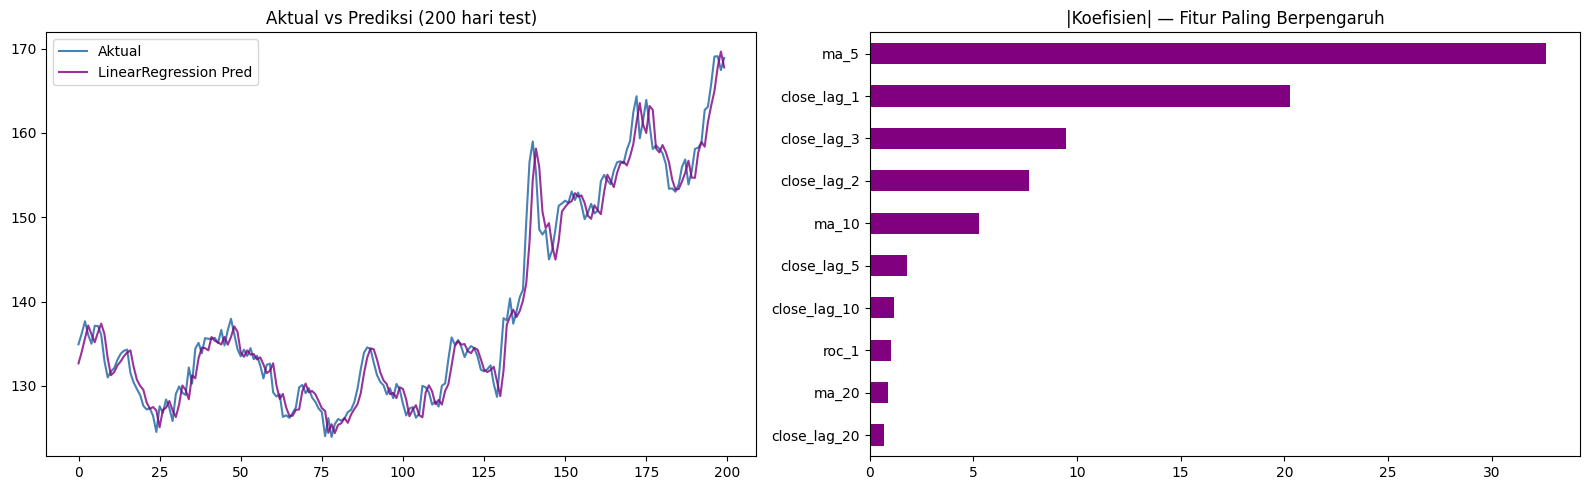

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(y_test[:200], label='Aktual', color='steelblue')
axes[0].plot(y_pred[:200], label=f'{best_name} Pred', color='purple', alpha=0.8)
axes[0].set_title('Aktual vs Prediksi (200 hari test)')
axes[0].legend()

# Koefisien model
coef = best_mdl.named_steps['m'].coef_
coef_series = pd.Series(np.abs(coef), index=feature_cols).sort_values(ascending=False).head(10)
coef_series.plot(kind='barh', ax=axes[1], color='purple')
axes[1].set_title('|Koefisien| — Fitur Paling Berpengaruh')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

### Interpretasi Koefisien:
- **Koefisien positif** pada `close_lag_1` → harga kemarin tinggi, maka besok juga cenderung tinggi
- **Koefisien negatif** pada `roc_1` → jika kemarin naik cepat, besok ada koreksi

### Catatan untuk Linear Regression & External Validity:
- R² tinggi bisa karena **autocorrelation** yang kuat (lag_1 hampir sama dengan target)
- Ujian sebenarnya: apakah bisa memprediksi **perubahan arah** harga?
- Gunakan **Directional Accuracy** sebagai metrik utama untuk trading signal

In [8]:
# RidgeCV — otomatis cari alpha terbaik
ridge_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100, 1000], cv=5))
])
ridge_cv.fit(X_train, y_train)
print(f'Best alpha: {ridge_cv.named_steps["model"].alpha_}')
yp_cv = ridge_cv.predict(X_test)
print(f'RidgeCV RMSE: {np.sqrt(mean_squared_error(y_test, yp_cv)):.4f}')

Best alpha: 0.001
RidgeCV RMSE: 3.3824


---
## 7.  Cara Mengoptimasi Model

### Strategi untuk Linear Regression:
1. **Tambah lebih banyak lag** — coba lags sampai 60 hari
2. **Polynomial features** — interaksi antar fitur
3. **Feature selection** — gunakan Lasso (otomatis nol-kan fitur tidak penting)
4. **Log transformation** — jika target sangat skewed

```python
from sklearn.preprocessing import PolynomialFeatures
model_poly = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True)),
    ('ridge', Ridge(alpha=10.0))
])
```

---
## 8.  Cara Menyimpan Model

In [9]:
os.makedirs('saved_models', exist_ok=True)
joblib.dump(ridge_cv, 'saved_models/ridge_stock.pkl')
joblib.dump(feature_cols, 'saved_models/feature_cols_ridge_stock.pkl')
print(' Ridge model tersimpan!')

 Ridge model tersimpan!


---
## 9.  Cara Menggunakan Model Hasil Training

In [10]:
loaded_model = joblib.load('saved_models/ridge_stock.pkl')
loaded_cols = joblib.load('saved_models/feature_cols_ridge_stock.pkl')
print('Model dimuat ')

last_row = df_feat.tail(1)[loaded_cols]
pred_price = loaded_model.predict(last_row.values)[0]
last_price = df_feat['Close'].iloc[-1]

print(f'\nHarga Close terakhir : ${last_price:.2f}')
print(f'Prediksi harga besok : ${pred_price:.2f}')
chg = (pred_price - last_price) / last_price * 100
print(f'Perkiraan perubahan  : {chg:+.2f}%')
print(f'Sinyal               : {" NAIK" if chg > 0 else " TURUN"}')

# Interpretasi koefisien
coef = loaded_model.named_steps['model'].coef_
top3 = pd.Series(coef, index=loaded_cols).abs().sort_values(ascending=False).head(3)
print(f'\nFitur paling berpengaruh:')
for fname, fval in top3.items():
    direction = '+' if coef[loaded_cols.index(fname)] > 0 else '-'
    print(f'  {direction} {fname}: |coef|={fval:.4f}')

Model dimuat 

Harga Close terakhir : $227.07
Prediksi harga besok : $222.61
Perkiraan perubahan  : -1.97%
Sinyal               :  TURUN

Fitur paling berpengaruh:
  + ma_5: |coef|=32.4260
  + close_lag_1: |coef|=20.3427
  - close_lag_3: |coef|=9.3928
